In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

In [2]:
cancer = 'BRCA'

def beta_to_m(beta):
    return np.log2(beta / (1 - beta))

train_path = '/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/tumor/train'
test_path = '/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/tumor/test'
meta_path = f'/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/metadata/tumor_metadata.csv'
xy_probes = pd.read_csv('/grain/mk98/cancer-methyl/probe_selection_files/xy_probes.txt', header=None)[0].tolist()

all_metadata = pd.read_csv(f'{meta_path}', index_col=0)

train_beta = pd.read_parquet(f'{train_path}/{cancer}_beta.parquet')
train_meta = all_metadata.loc[train_beta.index]
test_beta = pd.read_parquet(f'{test_path}/{cancer}_beta.parquet')
test_meta = all_metadata.loc[test_beta.index]

train_m = beta_to_m(train_beta)
test_m = beta_to_m(test_beta)

print(train_m.shape, test_m.shape)

# remove any samples with NA and remove XY probes
train_m = train_m.dropna().drop(columns=[x for x in xy_probes if x in train_m.columns])
test_m = test_m.dropna().drop(columns=[x for x in xy_probes if x in test_m.columns])

print(train_m.shape, test_m.shape)

(550, 293139) (235, 293139)
(550, 293139) (235, 293139)


In [3]:
from monte import Monte
monte = Monte()
monte.fit(train_m, train_meta['CPE'], additional_meta=train_meta)

Imported MONTE_cor package


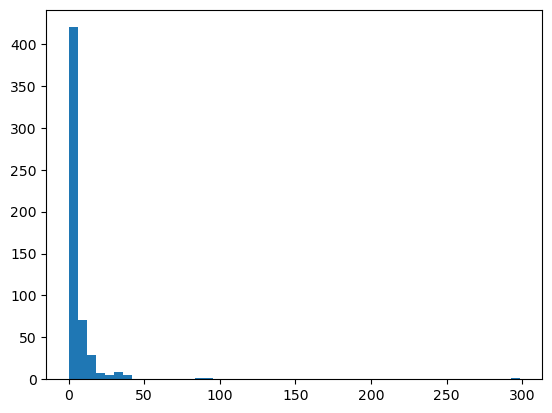

In [4]:
plt.hist(monte.sample_weights_, bins=50)
None

In [5]:
train_probe_corr = train_m.corrwith(train_meta['CPE'])

Text(0, 0.5, 'MONTE probe weights')

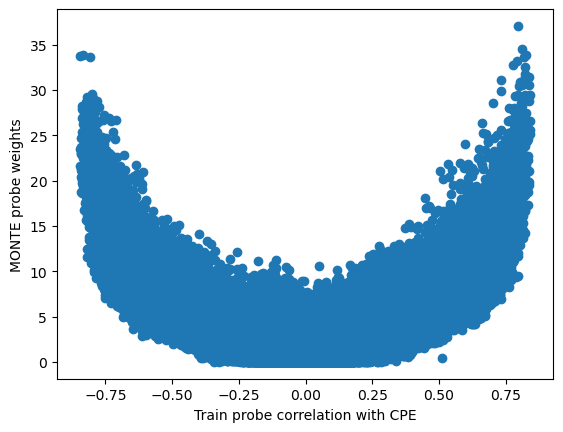

In [6]:
plt.scatter(train_probe_corr, monte.w_.values)
plt.xlabel('Train probe correlation with CPE')
plt.ylabel('MONTE probe weights')

# performance

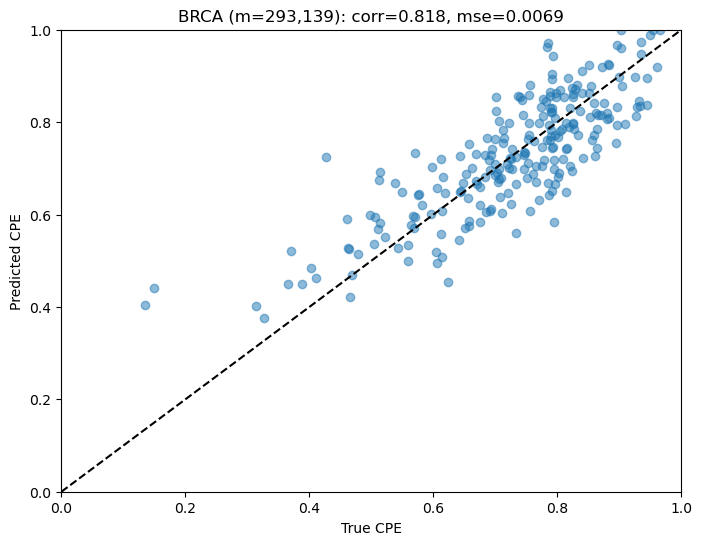

In [7]:
test_input = test_m.copy()
p_pred = monte.predict_purity(test_input)

plt.figure(figsize=(8,6))
plt.scatter(test_meta['CPE'], p_pred, alpha=0.5)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"{cancer} (m={test_input.shape[1]:,}): "
    f"corr={pearsonr(test_meta['CPE'], p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(test_meta['CPE'], p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

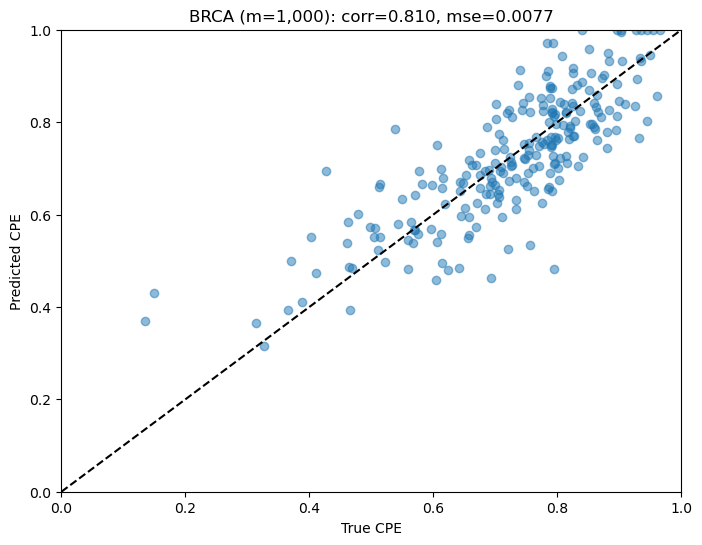

In [25]:
test_input = test_m.iloc[:, :1000].copy()

p_pred = monte.predict_purity(test_input)
plt.figure(figsize=(8,6))
plt.scatter(test_meta['CPE'], p_pred, alpha=0.5)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"{cancer} (m={test_input.shape[1]:,}): "
    f"corr={pearsonr(test_meta['CPE'], p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(test_meta['CPE'], p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# cell line

In [9]:
cellline_path = '/grain/mk98/cancer-methyl/external/celline_GSE68379'
cellline_beta = pd.read_parquet(f'{cellline_path}/GSE68379_all_beta.parquet').set_index('probe_id').T
cellline_meta = pd.read_parquet(f'{cellline_path}/GSE68379_all_meta.parquet').set_index('sample_id').reindex(cellline_beta.index)
cellline_beta = cellline_beta.drop(columns=[x for x in xy_probes if x in cellline_beta.columns]).dropna(axis=1)
cellline_m = beta_to_m(cellline_beta)

/home/mk98/miniconda3/envs/cancer/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


In [10]:
cellline_meta_cancer = cellline_meta[cellline_meta['project'] == cancer]
cellline_m_cancer = cellline_m.loc[cellline_meta_cancer.index]
print(cellline_m_cancer.shape, cellline_meta_cancer.shape)

(52, 467018) (52, 6)


/grain/mk98/github/MONTE/src/monte/main.py:79: RuntimeWarning: invalid value encountered in multiply
  num = np.nansum((Xc * b) * w * obs, axis=1)     # (n,)


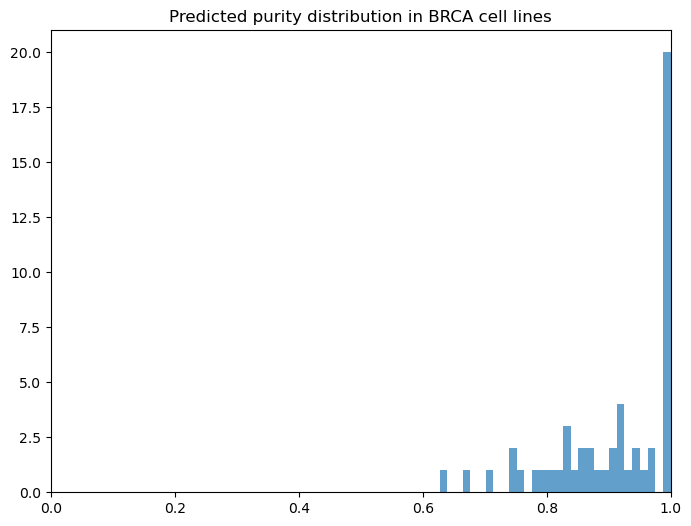

In [11]:
test_input = cellline_m_cancer.copy()

p_pred = monte.predict_purity(test_input)
plt.figure(figsize=(8,6))
plt.hist(p_pred, bins=30, alpha=0.7)
plt.xlim(0, 1)
plt.title(f'Predicted purity distribution in {cancer} cell lines')
plt.show()

# weight

In [5]:
train_probe_corr = train_m.corrwith(train_meta['CPE'])

Text(0, 0.5, 'MONTE weights')

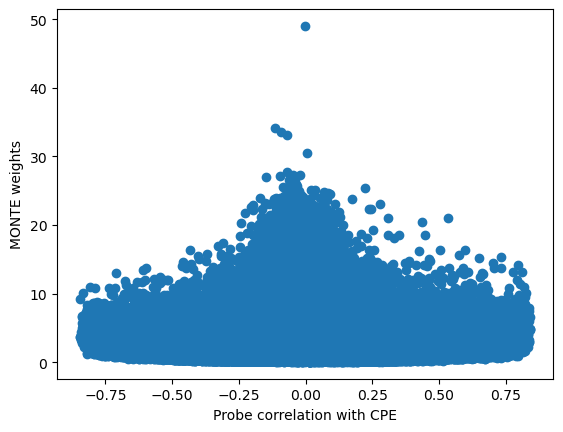

In [16]:
plt.scatter(train_probe_corr, monte.w_)
plt.xlabel('Probe correlation with CPE')
plt.ylabel('MONTE weights')

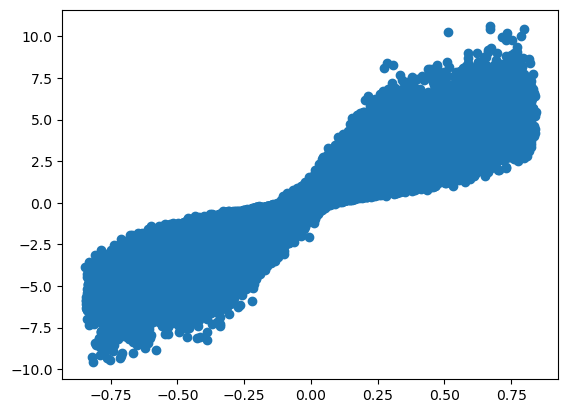

In [26]:
plt.scatter(train_probe_corr, monte.beta_)


Text(0, 0.5, 'MONTE weights')

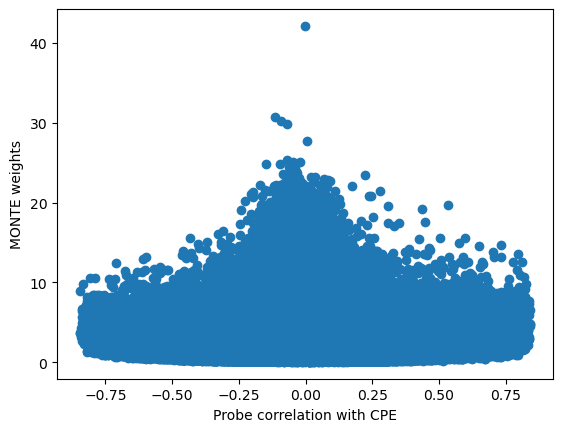

In [11]:
plt.scatter(train_probe_corr, monte.w_)
plt.xlabel('Probe correlation with CPE')
plt.ylabel('MONTE weights')

# check corr with pcawg

In [8]:
# pcawg brca CPE

icgc_to_tcga = pd.read_csv(f'/grain/mk98/cancer-methyl/external/pcawg/brca-us/icgc_to_tcga.csv')
pcawg_purity = test_meta['Patient'].map(icgc_to_tcga.set_index('submitter_id')['pcawg_purity'])
pcawg_purity = pcawg_purity.dropna()
overlap_meta = test_meta[test_meta.index.isin(pcawg_purity.index)].reindex(pcawg_purity.index)
overlap_m = test_m[test_meta.index.isin(pcawg_purity.index)].reindex(overlap_meta.index)

print(overlap_m.shape, overlap_meta.shape, pcawg_purity.shape)

(17, 293139) (17, 14) (17,)


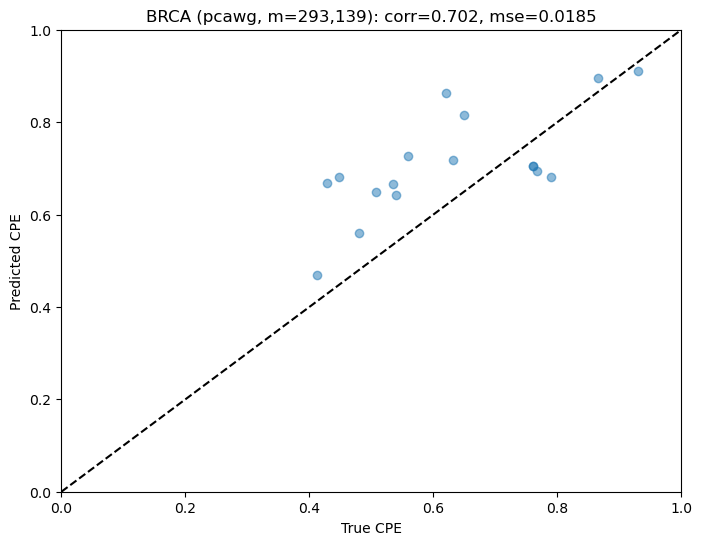

In [9]:
test_input = overlap_m.copy()

p_pred = monte.predict_purity(test_input)
plt.figure(figsize=(8,6))
plt.scatter(pcawg_purity.values, p_pred, alpha=0.5)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"{cancer} (pcawg, m={test_input.shape[1]:,}): "
    f"corr={pearsonr(pcawg_purity.values, p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(pcawg_purity.values, p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# PRAD

In [12]:
cancer = 'PRAD'

def beta_to_m(beta):
    return np.log2(beta / (1 - beta))

train_path = '/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/tumor/train'
test_path = '/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/tumor/test'
meta_path = f'/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/metadata/tumor_metadata.csv'
xy_probes = pd.read_csv('/grain/mk98/cancer-methyl/probe_selection_files/xy_probes.txt', header=None)[0].tolist()

all_metadata = pd.read_csv(f'{meta_path}', index_col=0)

train_beta = pd.read_parquet(f'{train_path}/{cancer}_beta.parquet')
train_meta = all_metadata.loc[train_beta.index]
test_beta = pd.read_parquet(f'{test_path}/{cancer}_beta.parquet')
test_meta = all_metadata.loc[test_beta.index]

train_m = beta_to_m(train_beta)
test_m = beta_to_m(test_beta)

print(train_m.shape, test_m.shape)

# remove any samples with NA and remove XY probes
train_m = train_m.dropna().drop(columns=[x for x in xy_probes if x in train_m.columns])
test_m = test_m.dropna().drop(columns=[x for x in xy_probes if x in test_m.columns])

print(train_m.shape, test_m.shape)

(349, 336634) (149, 336634)
(349, 336634) (149, 336634)


In [13]:
from monte import Monte
monte = Monte()
monte.fit(train_m, train_meta['CPE'])

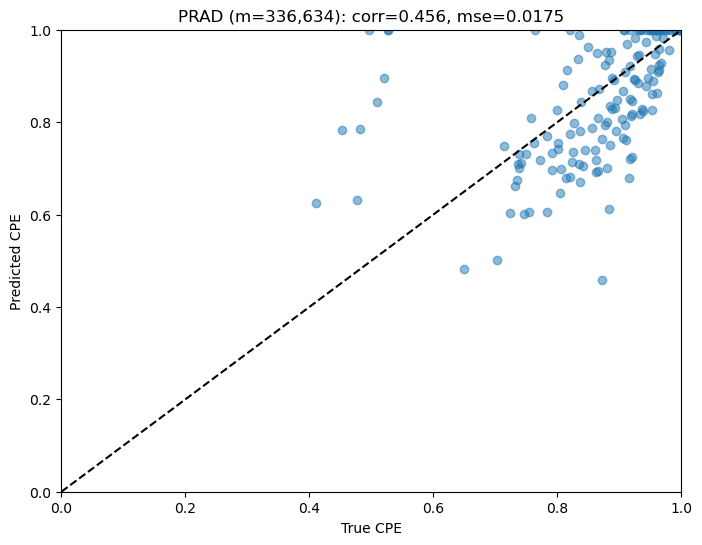

In [14]:
test_input = test_m.copy()
p_pred = monte.predict_purity(test_input)

plt.figure(figsize=(8,6))
plt.scatter(test_meta['CPE'], p_pred, alpha=0.5)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"{cancer} (m={test_input.shape[1]:,}): "
    f"corr={pearsonr(test_meta['CPE'], p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(test_meta['CPE'], p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

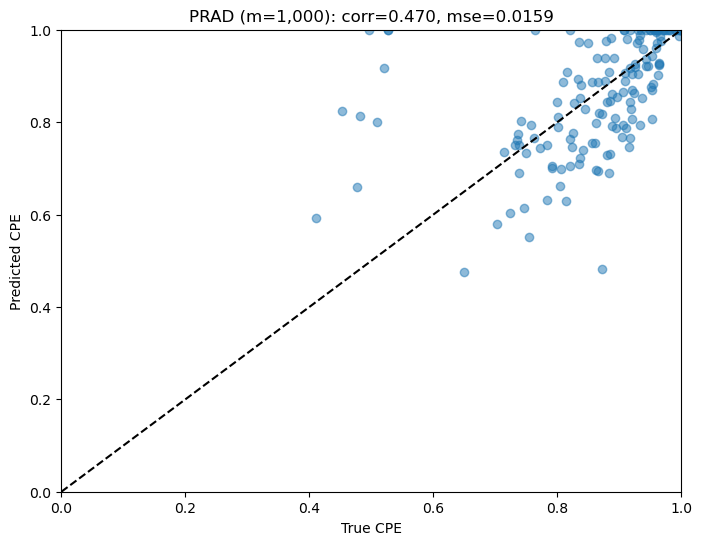

In [15]:
test_input = test_m.iloc[:, :1000].copy()

p_pred = monte.predict_purity(test_input)
plt.figure(figsize=(8,6))
plt.scatter(test_meta['CPE'], p_pred, alpha=0.5)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"{cancer} (m={test_input.shape[1]:,}): "
    f"corr={pearsonr(test_meta['CPE'], p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(test_meta['CPE'], p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [16]:
pcawg_path = '/grain/mk98/cancer-methyl/external/pcawg'
pcawg_beta = pd.read_parquet(f'{pcawg_path}/pcawg_prad_ca_beta.parquet').T
pcawg_meta = pd.read_parquet(f'{pcawg_path}/pcawg_prad_ca_meta.parquet').set_index('donor_id').reindex(pcawg_beta.index)

pcawg_m = beta_to_m(pcawg_beta)

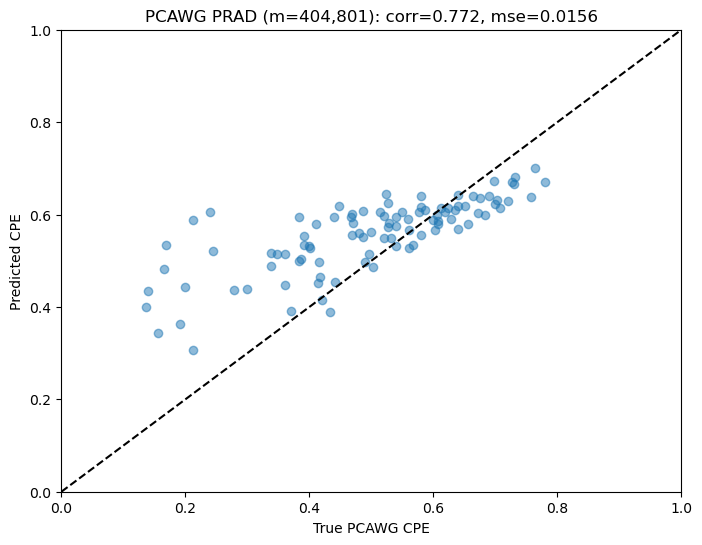

In [17]:
test_input = pcawg_m.copy()

p_pred = monte.predict_purity(test_input)
plt.figure(figsize=(8,6))
plt.scatter(pcawg_meta['purity'], p_pred, alpha=0.5)
plt.xlabel('True PCAWG CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"PCAWG {cancer} (m={test_input.shape[1]:,}): "
    f"corr={pearsonr(pcawg_meta['purity'], p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(pcawg_meta['purity'], p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [18]:
cellline_meta_cancer = cellline_meta[cellline_meta['project'] == cancer]
cellline_m_cancer = cellline_m.loc[cellline_meta_cancer.index]
print(cellline_m_cancer.shape, cellline_meta_cancer.shape)

(10, 467018) (10, 6)


/grain/mk98/github/MONTE/src/monte/main.py:79: RuntimeWarning: invalid value encountered in multiply
  num = np.nansum((Xc * b) * w * obs, axis=1)     # (n,)


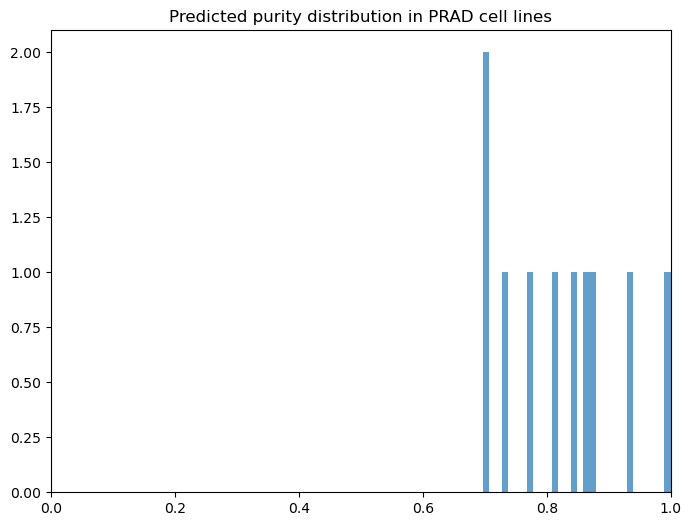

In [19]:
test_input = cellline_m_cancer.copy()

p_pred = monte.predict_purity(test_input)
plt.figure(figsize=(8,6))
plt.hist(p_pred, bins=30, alpha=0.7)
plt.xlim(0, 1)
plt.title(f'Predicted purity distribution in {cancer} cell lines')
plt.show()

In [23]:
train_probe_corr = train_m.corrwith(train_meta['CPE'])

Text(0, 0.5, 'MONTE beta coefficients')

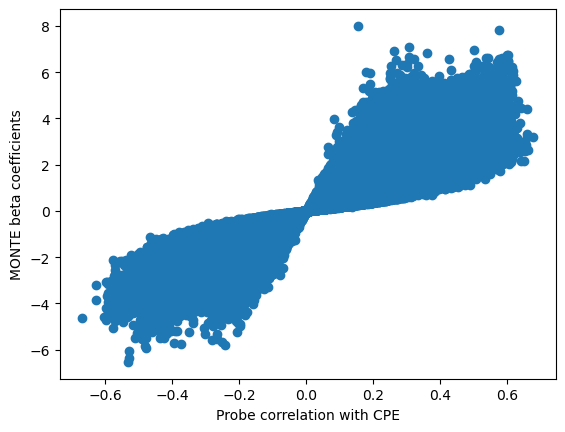

In [24]:
plt.scatter(train_probe_corr, monte.beta_)
plt.xlabel('Probe correlation with CPE')
plt.ylabel('MONTE beta coefficients')

Text(0, 0.5, 'MONTE weights')

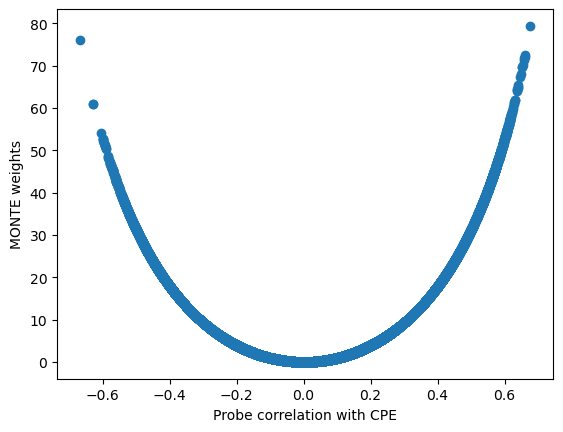

In [25]:
plt.scatter(train_probe_corr, monte.w_)
plt.xlabel('Probe correlation with CPE')
plt.ylabel('MONTE weights')

# pan

In [29]:
def beta_to_m(beta):
    return np.log2(beta / (1 - beta))

train_path = '/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/pan/tumor/train'
test_path = '/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/pan/tumor/test'
meta_path = f'/grain/mk98/cancer-methyl/TCGA_Methylation_450K/processed/metadata/tumor_metadata.csv'
xy_probes = pd.read_csv('/grain/mk98/cancer-methyl/probe_selection_files/xy_probes.txt', header=None)[0].tolist()

all_metadata = pd.read_csv(f'{meta_path}', index_col=0)

train_beta = pd.read_parquet(f'{train_path}/pan-cancer_beta.parquet')
train_meta = all_metadata.loc[train_beta.index]
test_beta = pd.read_parquet(f'{test_path}/pan-cancer_beta.parquet')
test_meta = all_metadata.loc[test_beta.index]

train_m = beta_to_m(train_beta)
test_m = beta_to_m(test_beta)

print(train_m.shape, test_m.shape)

# remove any samples with NA and remove XY probes
train_m = train_m.dropna().drop(columns=[x for x in xy_probes if x in train_m.columns])
test_m = test_m.dropna().drop(columns=[x for x in xy_probes if x in test_m.columns])

print(train_m.shape, test_m.shape)

(4928, 163290) (2112, 163290)
(4928, 163290) (2112, 163290)


In [30]:
from monte import Monte
monte = Monte()
monte.fit(train_m, train_meta['CPE'])

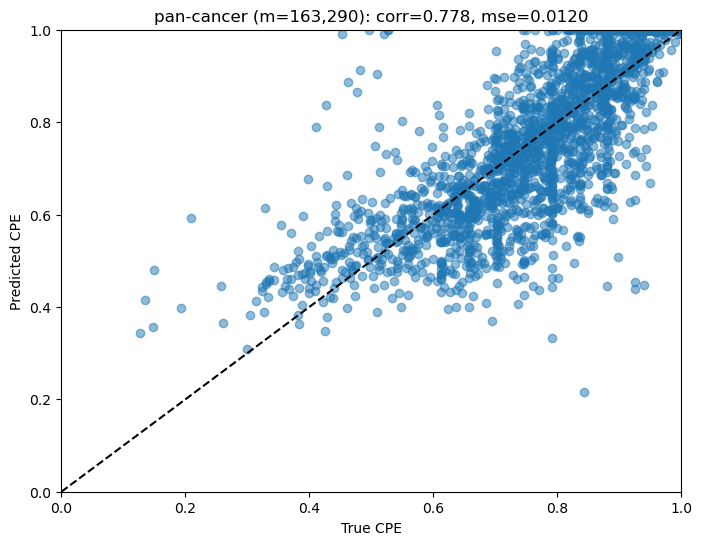

In [6]:
test_input = test_m.copy()
p_pred = monte.predict_purity(test_input)

plt.figure(figsize=(8,6))
plt.scatter(test_meta['CPE'], p_pred, alpha=0.5)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.title(
    f"pan-cancer (m={test_input.shape[1]:,}): "
    f"corr={pearsonr(test_meta['CPE'], p_pred)[0]:.3f}, "
    f"mse={mean_squared_error(test_meta['CPE'], p_pred):.4f}"
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

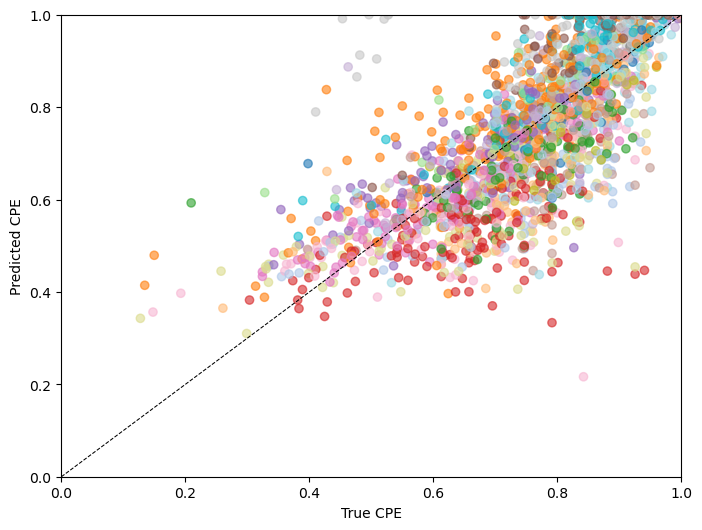

In [7]:
p_pred_series = pd.Series(p_pred, index=test_meta.index, name='predicted_purity')
meta_with_pred = test_meta.join(p_pred_series)

# Color by cancer type using a categorical palette
cmap = plt.get_cmap('tab20')
cats = meta_with_pred['Cancer.type'].astype('category')
colors = cats.cat.codes.map(lambda i: cmap(i % cmap.N))

plt.figure(figsize=(8,6))
plt.scatter(meta_with_pred['CPE'], meta_with_pred['predicted_purity'], c=list(colors), alpha=0.6)
plt.xlabel('True CPE')
plt.ylabel('Predicted CPE')
plt.plot([0, 1], [0, 1], 'k--', lw=0.75)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [9]:
meta_with_pred.groupby('Cancer.type').apply(
    lambda df: pearsonr(df['CPE'], df['predicted_purity'])[0]
)


/tmp/ipykernel_3983377/3605510247.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meta_with_pred.groupby('Cancer.type').apply(


Cancer.type
ACC     0.975906
BLCA    0.704617
BRCA    0.810031
CESC    0.740675
COAD    0.659015
GBM     0.844600
HNSC    0.616294
KICH    0.968739
KIRC    0.831778
KIRP    0.815896
LGG     0.785822
LIHC    0.672851
LUAD    0.868443
LUSC    0.701108
OV      0.912592
PRAD    0.465224
READ    0.715977
SKCM    0.779694
THCA    0.902691
UCEC    0.781172
UCS     0.513378
dtype: float64

In [12]:
import gzip 

soft_path = "/grain/mk98/cancer-methyl/external/cf_coad_GSE186381/GSE186381_family.soft.gz"
metadata = []

with gzip.open(soft_path, "rt") as f:
    sample = {}
    for line in f:
        if line.startswith("^SAMPLE"):
            if sample:
                metadata.append(sample)
            sample = {"sample_id": line.strip().split(" = ")[1]}
        elif line.startswith("!Sample_title"):
            sample["title"] = line.strip().split(" = ")[1]
        elif line.startswith("!Sample_characteristics_ch1"):
            keyval = line.strip().split(" = ")[1]
            if ":" in keyval:
                key, val = keyval.split(":", 1)
                sample[key.strip()] = val.strip()
    if sample:
        metadata.append(sample)

meta_df = pd.DataFrame(metadata)
meta_df.head()

,sample_id,title,pathology,sample type,molecule type
0,GSM5646628,No colorectal findings cfDNA pool A1,NCF,serum,circulating cell-free DNA
1,GSM5646629,Benign pathologies cfDNA pool A2,BEN,serum,circulating cell-free DNA
2,GSM5646630,Non-advanced adenomas cfDNA pool A3,NAA,serum,circulating cell-free DNA
3,GSM5646631,Distal advanced adenomas cfDNA pool A4,D-AA,serum,circulating cell-free DNA
4,GSM5646632,Proximal advanced adenomas cfDNA pool A5,P-AA,serum,circulating cell-free DNA


In [ ]:
def read_matrix(path):
    with gzip.open(path, "rt") as f:
        # Skip header lines starting with '!'
        lines = [line for line in f if not line.startswith('!')]
    from io import StringIO
    return pd.read_csv(StringIO(''.join(lines)), sep='\t', index_col=0)

matrix_450k = read_matrix("GSE35069_series_matrix.txt.gz")

# Show shapes and a preview
print("450K shape:", matrix_450k.shape)
matrix_450k.iloc[:5, :5]